In [2]:
import sys
sys.path.append("..")

import pandas as pd
import quantstats as qs
from data.loader import download_data, compute_returns
from backtester.engine import Backtester
from backtester.metrics import full_metrics

In [3]:
data = download_data("AAPL", "2018-01-01", "2024-01-01")
data = compute_returns(data)

bt = Backtester(data, initial_capital=10000)
output = bt.run(window=20)
results = output["results"]

In [5]:
metrics = output["metrics"]

print("=" * 40)
print("   MÉTRIQUES COMPLÈTES")
print("=" * 40)
for k, v in metrics.items():
    print(f"{k:25} : {v}")


   MÉTRIQUES COMPLÈTES
CAGR (%)                  : 33.55
Sharpe                    : 1.52
Calmar                    : 1.49
Max Drawdown (%)          : -22.47
Win Rate (%)              : 54.64
Profit Factor             : 1.4
VaR 95% (%)               : -1.88
Capital final (€)         : 56486.23
Nb jours tradés           : 949



Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2018-02-15   2018-02-15
End Period                 2023-12-29   2023-12-29
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       65.0%

Cumulative Return          94.95%       464.86%
CAGR﹪                     12.06%       34.34%

Sharpe                     0.66         1.54
Prob. Sharpe Ratio         94.3%        99.99%
Smart Sharpe               0.65         1.51
Sortino                    0.92         2.39
Smart Sortino              0.9          2.34
Sortino/√2                 0.65         1.69
Smart Sortino/√2           0.64         1.66
Omega                      1.13         1.4

Max Drawdown               -33.72%      -22.47%
Max DD Date                2020-03-23   202

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2020-09-02,2021-03-24,2021-11-17,442,-22.474501,-21.935033
2,2018-09-05,2019-01-29,2019-03-20,197,-19.891837,-18.296706
3,2022-03-30,2022-06-28,2022-08-12,136,-19.537179,-18.013963
4,2022-08-18,2023-01-12,2023-02-02,169,-12.540933,-11.655962
5,2019-08-01,2019-08-27,2019-10-09,70,-9.850064,-9.775479


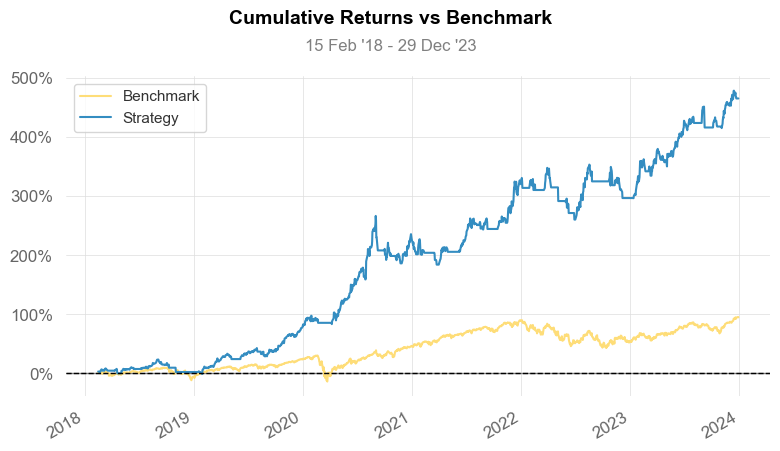

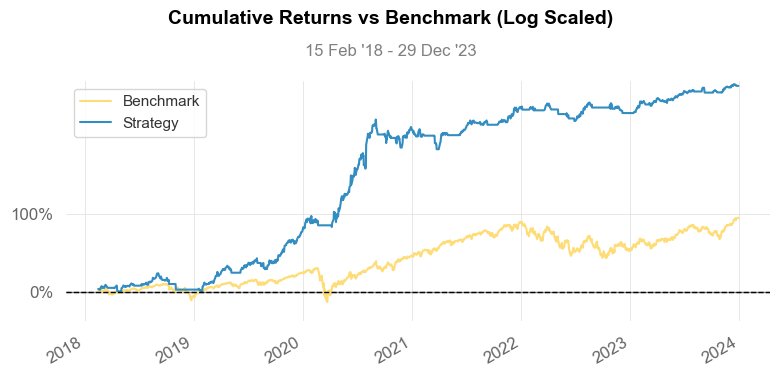

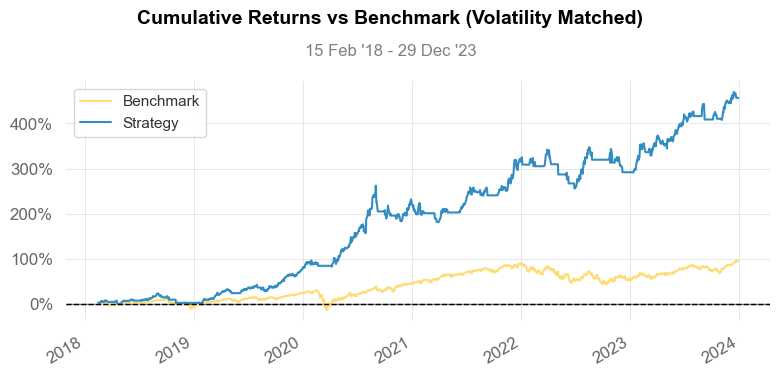

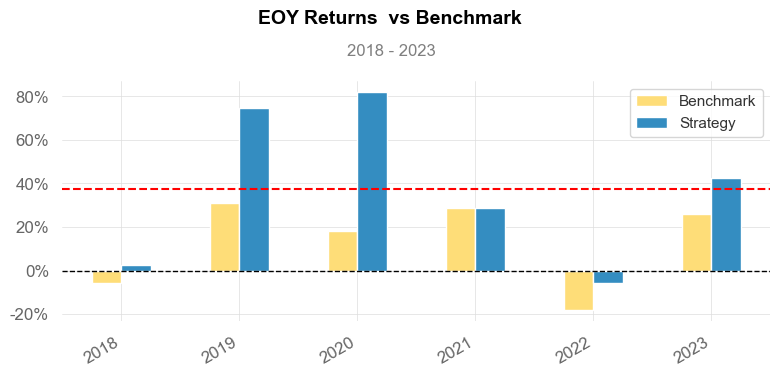

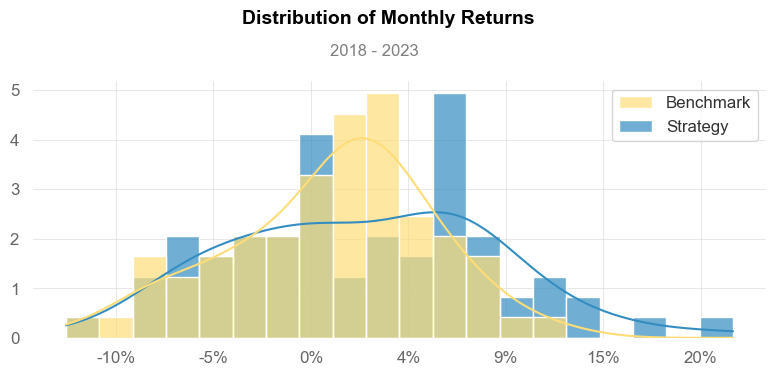

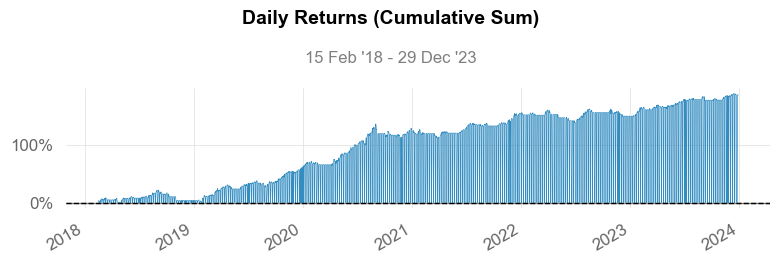

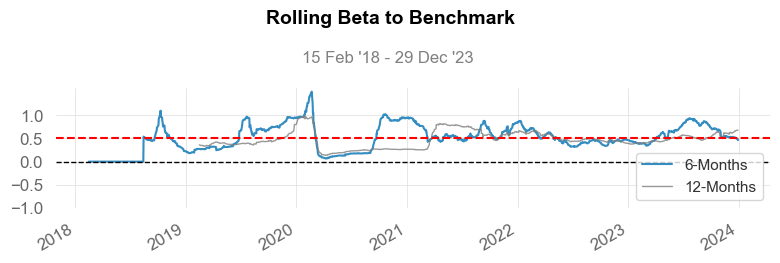

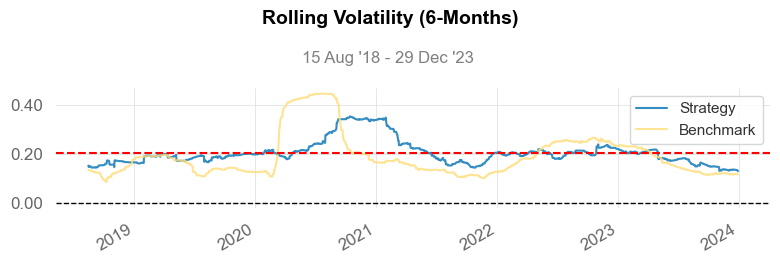

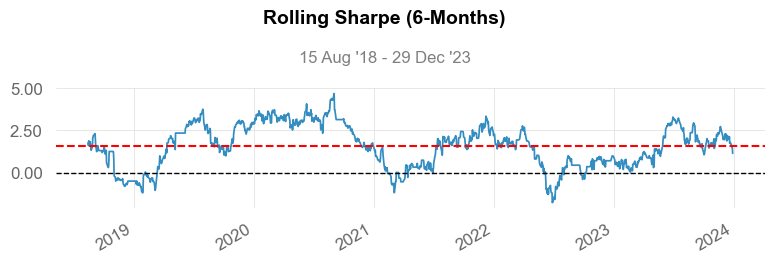

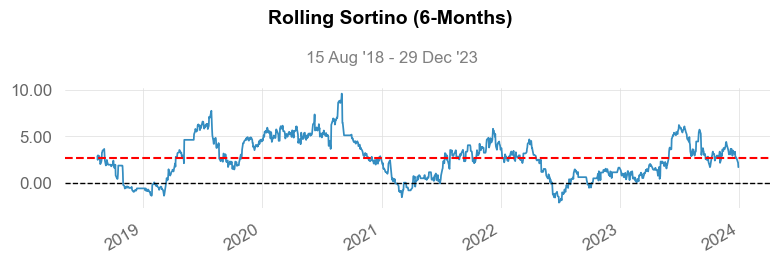

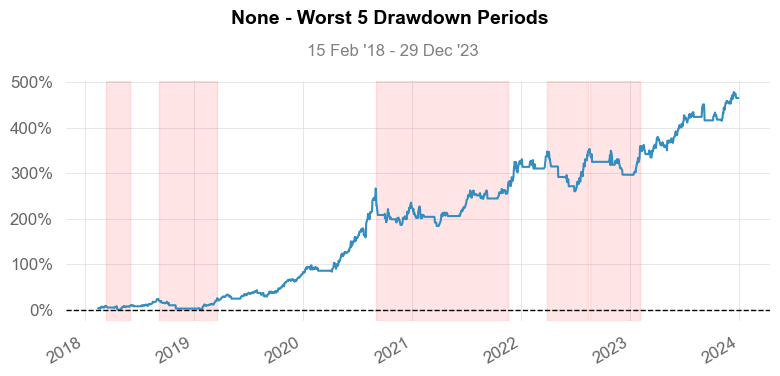

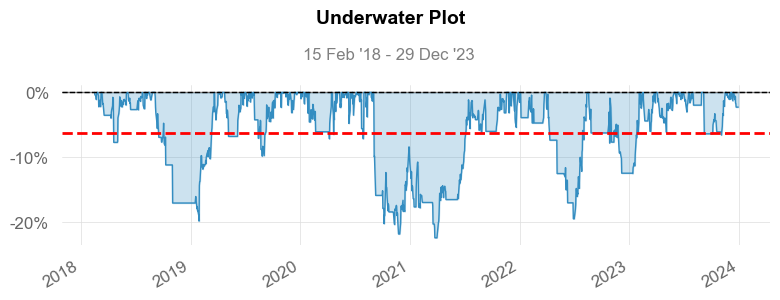

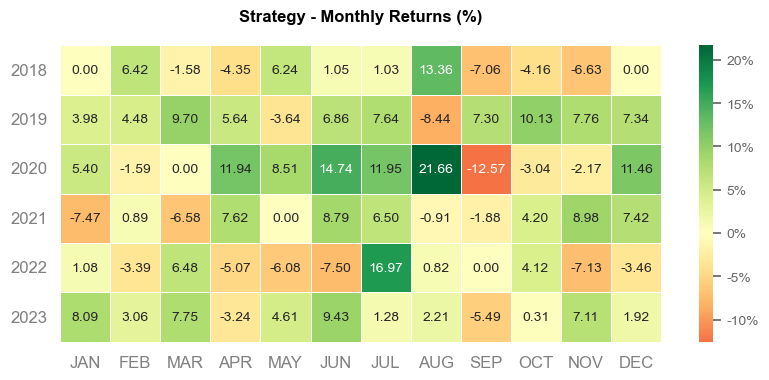

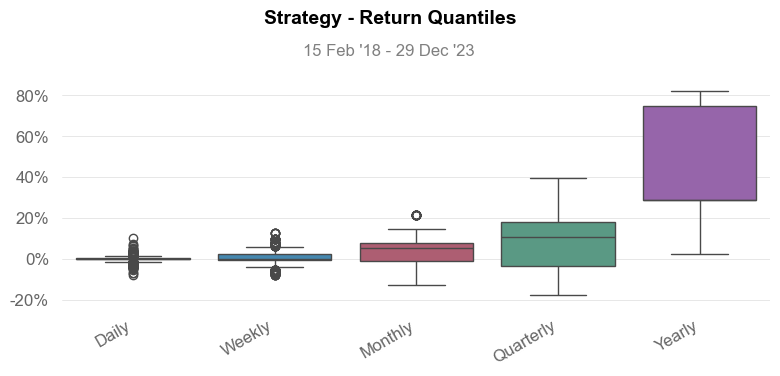

In [6]:
import os
os.makedirs("../reports", exist_ok=True)

strategy_returns = results["strategy_returns"].dropna()

# Affiche le tearsheet directement dans le notebook
qs.reports.full(strategy_returns, benchmark="SPY")

In [7]:
# Récupère les rendements de la stratégie
strategy_returns = results["strategy_returns"].dropna()

# Tearsheet complet avec comparaison au S&P 500
qs.reports.html(
    strategy_returns,
    benchmark="SPY",
    output="../reports/tearsheet_AAPL_SMA20.html",
    title="SMA 20 jours — AAPL"
)

print("Tearsheet généré dans reports/tearsheet_AAPL_SMA20.html")

Tearsheet généré dans reports/tearsheet_AAPL_SMA20.html


In [8]:
# Tu peux aussi appeler chaque métrique séparément
print(f"Sharpe (quantstats)  : {qs.stats.sharpe(strategy_returns):.2f}")
print(f"Sortino              : {qs.stats.sortino(strategy_returns):.2f}")
print(f"Max Drawdown         : {qs.stats.max_drawdown(strategy_returns)*100:.2f}%")
print(f"Volatilité annuelle  : {qs.stats.volatility(strategy_returns)*100:.2f}%")
print(f"CAGR                 : {qs.stats.cagr(strategy_returns)*100:.2f}%")

Sharpe (quantstats)  : 1.52
Sortino              : 2.36
Max Drawdown         : -22.47%
Volatilité annuelle  : 20.35%
CAGR                 : 33.55%
